# RED-CNN Model - Performance of Different Variants

In this notebook we display some results that were gotten from the ```RED-CNN``` Model different variants.

---

The results are shown for different versions of the model:
*   Baseline model trained and tested on ```MAYO``` dataset
*   Baseline model trained and tested on ```MAR``` dataset
*   Baseline model trained on ```MAYO``` dataset with fine-tuned decoder on ```MAR``` datset

---

Images display format:

**Input** (low-dosed / metal artifacts corrupted image)   **||**   **Net** output image **||**  **GT** (normal-dosed / clean) image


TODO:
*   add averaged measurments and in this way compare and analyze
*   add architectures graphs: torch.save(model, "model.pth") then enter the website netron.app and drag this saved file - this will create the graph



### Part A | Training and Testing Baseline Model on MAYO dataset
In the very start, we directly pulled the proven, working model of RED CNN from a known git repository. After adjustments to Google Colab enviorment and organizing the data set, we succssefuly restored the great performance shown in our academic reference.
Here we show:


1.   Net Performance on test set (patient L506)
2.   Losses plots (validition patient L109)
---
It can be seen that the output images which are produced by the deep net, **have much better quality and similarity for the gt**, Normal Dosed images (in terms of RMSE, SSIM, and PSNR). However, the losses graph is seem to have some bumps on the validition set - so a scheduler for the learning rate should be considered.

source notebook: Basic RED-CNN Model MAYO

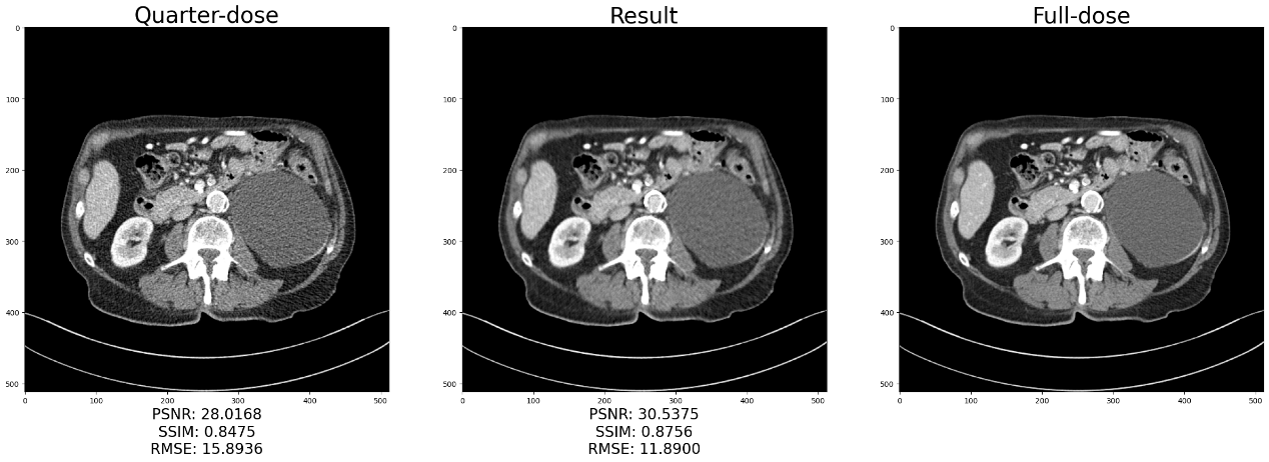

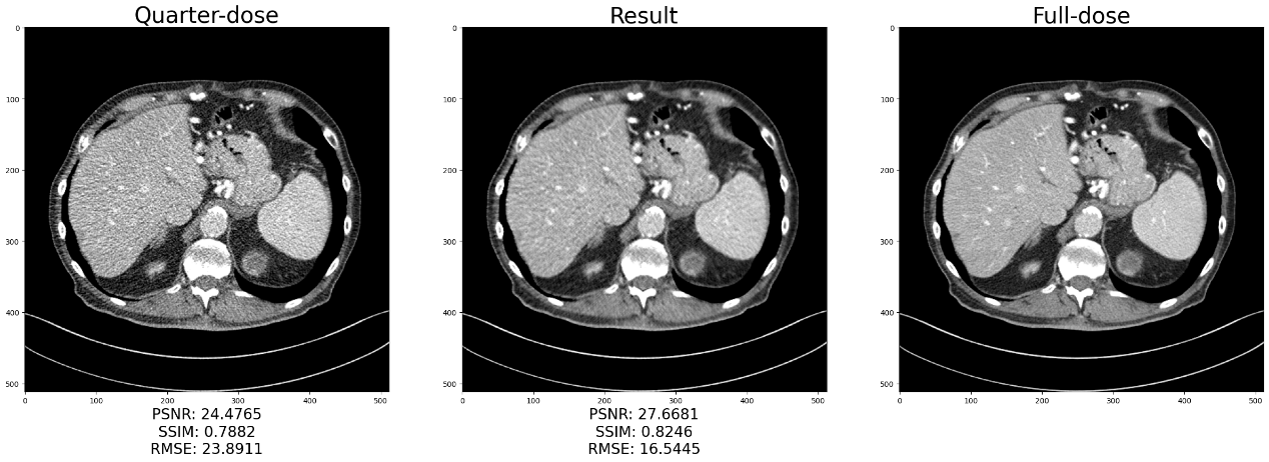

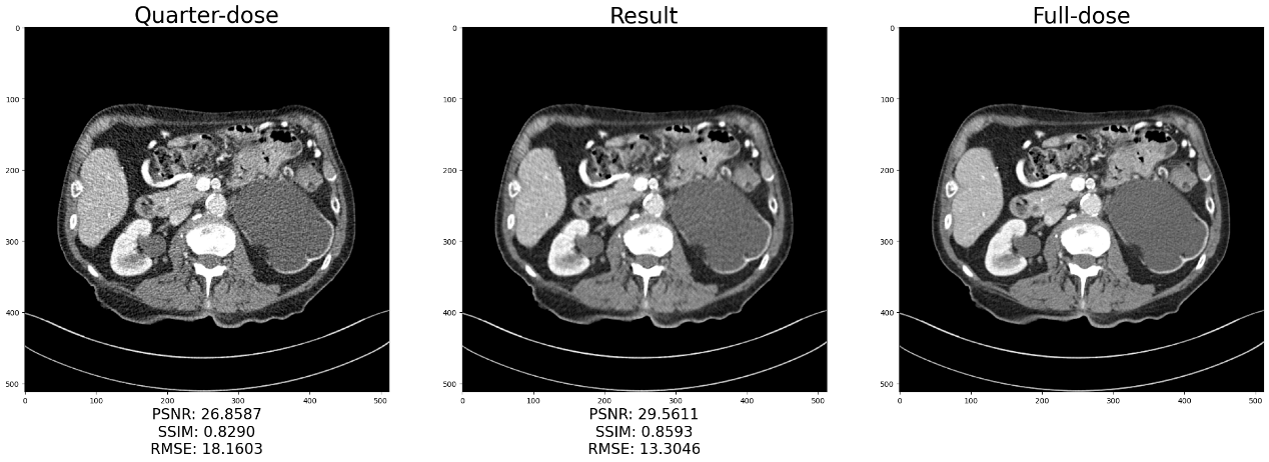

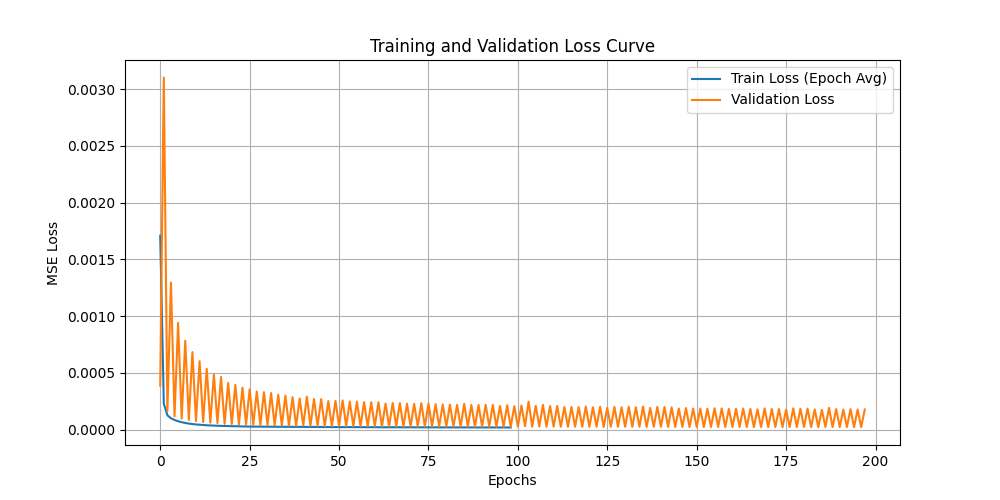

### TODO: add here another training results where the step size is decreased, so there are no osiclations like above!

### Part B | Training and Testing Baseline Model on MAR dataset
Next, we tried to examine the RED CNN model performance on other data set - Metal Artifacts Removal.


Here we show, for training + testing new RED CNN model on MAR dataset :
1.   Net Performance on test set (8% taken equaly from every body data folder)
2.   Losses plots (validition was 5% taken equaly from every body data folder)

In section (1) we show a net whose weigths were initialized with zeros, and in section (2) we show a fine tune: the net weigths were initialized to the 12000-iterations model that we get from MAYO training (the most updated model of the mentioned training)

---
It can be seen that the output images which are produced by the deep net, **have better quality compared with the input images** (mainly in terms of RMSE and PSNR). However, the metal artifacts are still can be seen in the net output, and also a blur can be clearly spotted - so there is a room for improvment. (will be treated in chapter _, new architecture / optimization attitude)

source notebook: Basic RED-CNN Model MAR

(1) zero initialization

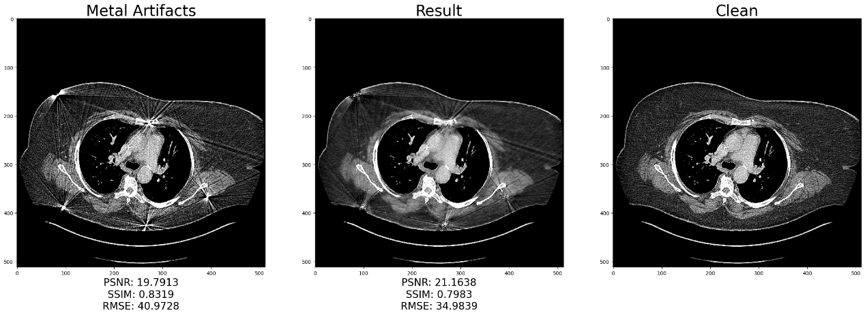

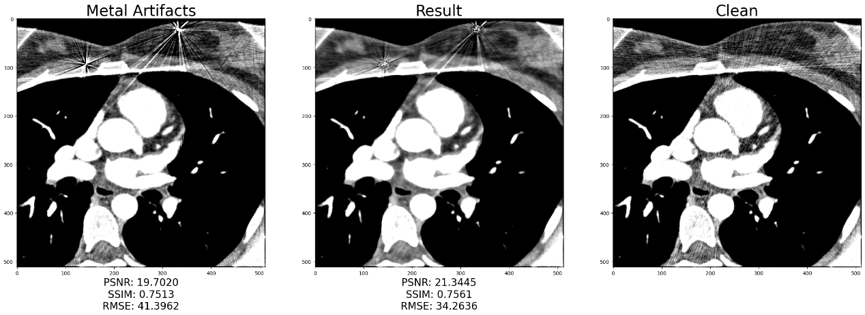

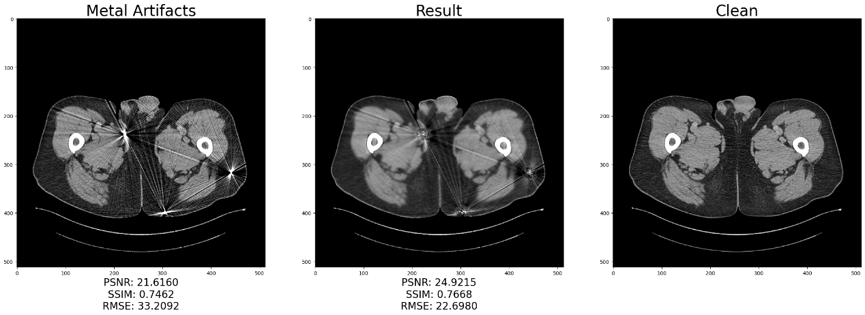

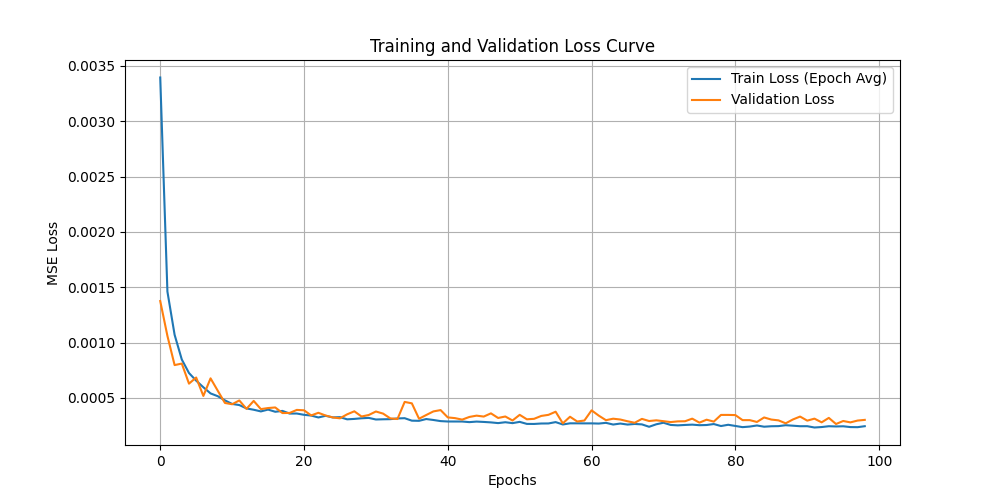

(2) complete fine tuning

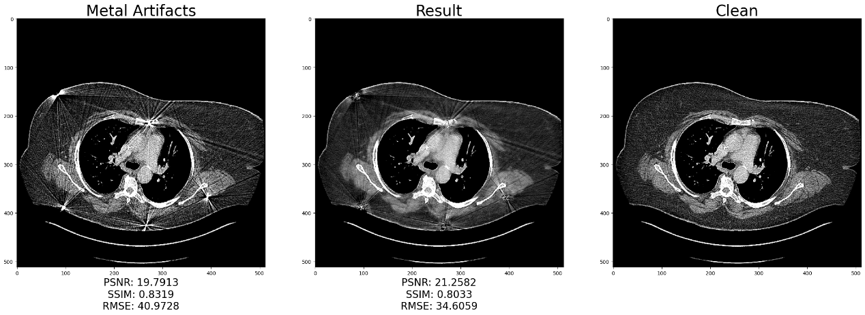

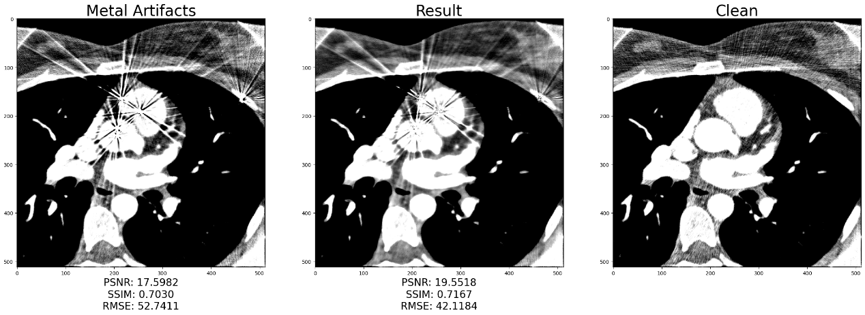

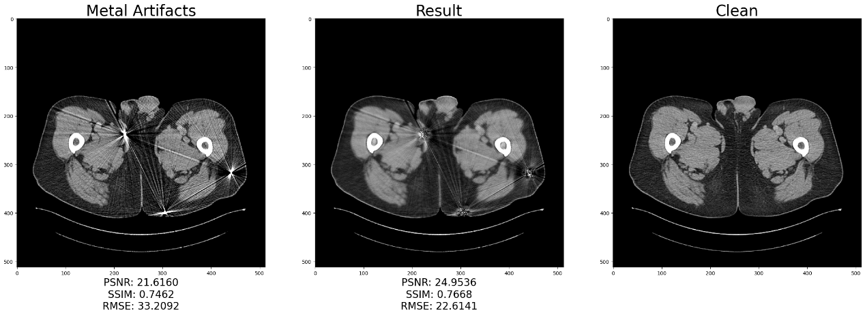

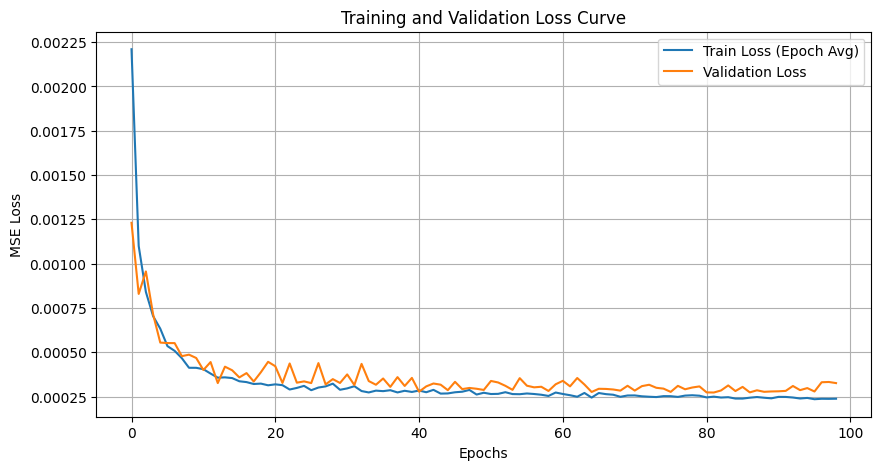

### Part C | Fine-Tuning MAYO-trained Model Decoder on MAR
Our main goal here is to both save time and preserve good performance of RED CNN on the new MAR dataset - which means, to avoid full training and testing on MAR.
First of all, we examined the generalization of the MAYO-trained Model on the MAR data set. As can be shown in section (1), the performance wasn't very good. So, we cant entirely save the whole time, and we must train a new model.

We would like to observe whether we can save time by utilizing the advantage of encoder-decoder architecture that we learned in class.
In section (2), we took the model we trained on part A, then we fine-tuned only the decoder on the new MAR dataset.

why we did it? distribution (...)

---
results anlyze:
*   start from good loss, not like before (...)
*   List item

(mention the one with no patches? maybe in another seperate part)

source notebook: Basic RED-CNN Model MAR

#### (1) Mayo-trained and Mar-tested

#### (2) Mayo-trained, then Mar-fine tuned decoder, then testing on Mar

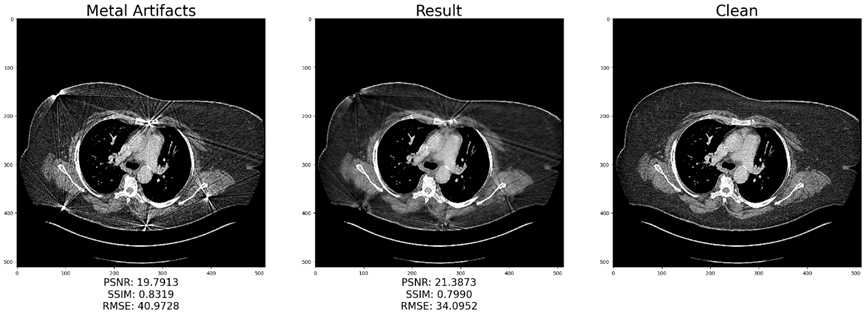

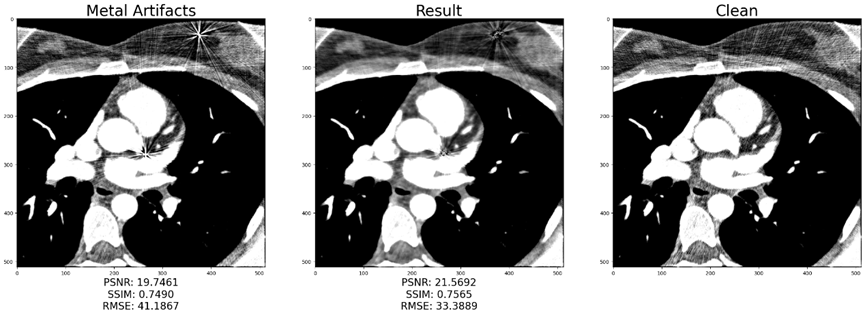

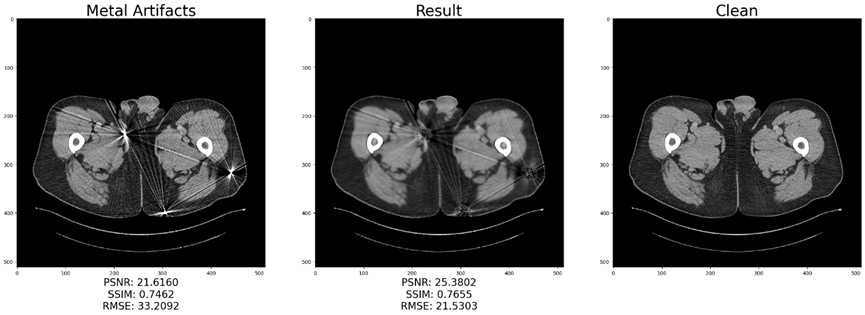

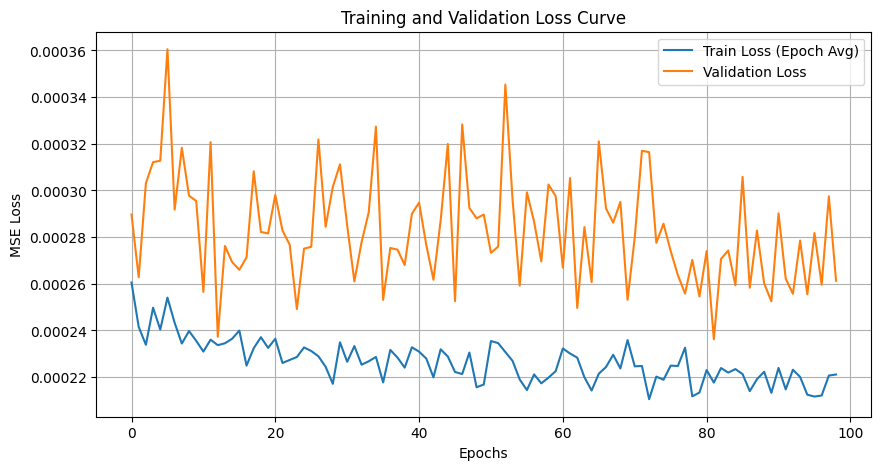

### Interim Summary - Performance of Classic RED CNN implementation on new MAR dataset
After observing a couple of different methods to fit the classic RED CNN architecture to the new data set, we can observe the performance of the different methods.
A way we found proper to compare between the different methods is considering the average delta between the input (the image with metal artifacts) and the net output in 3 different conventional mesurments for images comparation: RMSE, PSNR and SSIM. The measurments are taken in refer to the gt (clean images).

Since the delta of measure M is M(net) - M(in), the interperation should be:
*   higher, positive delta PSNR is better.
*   higher, positive delta SSIM is better.
*   lower, negative delta RMSE is better.

The averaged results on MAR test set are as follows:

| Model creating method | Avg delta PSNR | Avg delta SSIM | Avg delta RMSE |
|----------|------|-------|------:|
| MAYO trained model | 0.55 | -0.011 | -1.65 |
| **MAYO trained model with decoder fine-tune on MAR** | **1.94** | **-0.01** | **-7.01** |
| MAYO trained model with complete fine-tune on MAR | 1.8 | -0.01 | -6.6 |
| MAR trained model | 1.73 | -0.01 | -6.34 |

Interstingly, the most optimal model was the one that had a fine tuned decoder. We can infer that the encoder-decoder architecture was to our advantage.

Yet, compared with the better performance of RED CNN on MAYO test set:

**TODO**: complete after running test in notebook
| Model creating method | Avg delta PSNR | Avg delta SSIM | Avg delta RMSE |
|----------|------|-------|------:|
| MAYO trained model |  |  |  |

And because we still see shadows of the metal artifacts in the net output on MAR, we would have wanted to make more adjustments to the architecture of RED CNN and to the optimization process, and make our model more fit to the MAR dataset.

### Part D | Enhancing RED CNN Implementation for MAR dataset

We divided the changes we made into 2 main categories:
1.   Architecture reconsidering: we modified the structure of the net
2.   Optimization and hyper parameters: we rechoosed some hyper parameters and loss function

Concise version of the innovations and their reasons is as follows:
| Category | Description | Old | New | Reason |
|--------------|-------------|-----|-----|-------:|
| 1 | Dilated 2Dconv (encoder) | p=0, d=1 | p=4, d=2 | increase RF without adding params
| 1 | Norm layers | no Norm Layers | Instance Normalization | better artifact decoupling
| 1 | skip connections | additive | concatenative | better details preserving
| 2 | learning step size | 1e-5 | 3.033e-5 | Optuna |
| 2 | loss function (L) | MSE loss | L1 + SSIM loss | L1 + SSIM more feasible for MAR |  
| 2 | weight of  SSIM in L | ~ | 0.623 | Optuna |

Full details are in report.


#### Results
after running the optuna and modifing the architecture, we run anew our MAR training and get new results.